In [3]:
# Brug en pæn stil til alle plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')  

# FORELÆSNING 11: Datavisualisering og unsupervised læring

> Exploratory Data Analysis, visualiseringsmetoder, k-means clustering og opdagelse af mønstre uden labels.

### Underviser: Martin Siemienski Andersen mvan@hst.aau.dk

**ST2 - Anvendt Programmering**

# ST2 ANVENDT PROGRAMMERING - Overblik

## Alle forelaesninger



In [4]:
from IPython.display import HTML
import requests

url = "https://raw.githubusercontent.com/AAU-ST2-Programming/all_lectures/refs/heads/main/overview_files/shared_overview_table11.html"
html = requests.get(url, timeout=30).text
HTML(html)

#,Forelæsning,Mappe,Primære emner
1,Hej C og Python,oop_1,"Programmeringssprog, grundlæggende syntaks, miljøopsætning"
2,"Objekter, indkapsling, interaktion",oop_2,"Klasser, metoder, dataindkapsling, objektinteraktion"
3,Filer og dataindlæsning,oop_3,Fra tekstfil til objekter
4,OOP-integration workshop,oop_4_workshop,"Integration af OOP, fil-I/O, visualisering; overvågningssystemer til enheder"
5,Signalgrundlag,signals_1,"EKG-fysiologi, statistik, peak-detektion"
6,Filtrering og mekaniske signaler,signals_2,"Filtrering, SCG-fysiologi, mekanisk timing, Envelope-udtrækning"
7,"Feature engineering, PPG og regression",signals_3,"Feature-definition, PPG-fysiologi, lineær regression, variationsmål"
8,Signalintegration og etik,signals_4_workshop,"Multimodal integration, refleksion over signal-workflow, etisk analyse"
9,Review af Python Serial Recorder,python_serial_recorder,"Gennemgang af Python Serial Recorder, diskussion af anvendelser og forbedringer"
10,Lineær regression med populationsdata,populations_data_1,"Lineær regression, modelvalidering, residualer"


# Unsupervised learning vs. supervised learning
- **Unsupervised learning**: Læring uden mærkede data. Modellen forsøger at finde mønstre eller strukturer i dataene uden nogen foruddefinerede etiketter.
- **Supervised learning**: Læring med mærkede data. Modellen trænes på et datasæt, hvor hver indgang har en tilknyttet etiket, og målet er at lære en funktion, der kan forudsige etiketterne for nye, usete data.



# Clustering vs. Klassifikation vs. Regression
**Regression**: En type supervised learning
- Målet er at forudsige en kontinuerlig værdi for hver indgang. 
- Eksempler inkluderer at forudsige huspriser baseret på forskellige funktioner eller at forudsige temperaturen baseret på historiske data.

**Klassifikation**: En type supervised learning  
- Målet er at forudsige en diskret etiket eller klasse for hver indgang. 
- Eksempler inkluderer at klassificere e-mails som spam eller ikke-spam, eller at genkende håndskrevne cifre.

**Clustering**: En type unsupervised learning
- Målet er at gruppere data i klynger baseret på ligheder uden at have foruddefinerede labels. 
- Eksempler inkluderer at segmentere kunder i forskellige grupper baseret på deres købsadfærd eller at identificere mønstre i geografiske data.






# K-means clustering i biomedicinsk databehandling

- Hvad k-means er
- Hvordan det beregnes i hånden
- Hvordan man visualiserer og evaluerer klynger
- Hvordan man bruger scikit-learn
- Hvordan man segmenterer et billede
- Hvordan man vurderer performance og fortolker data

## Hvad k-means er

K-means er en algoritme, der opdeler data i k grupper baseret på afstand.

- Hver gruppe repræsenteres af en centroid
- Algoritmen minimerer den samlede afstand mellem datapunkter og deres nærmeste centroid
- Bruges i biomedicinsk ingeniørvidenskab til fx signalanalyse, biomarkører og billeddata, hvor labels ofte mangler

## Hvordan k-means fungerer

Algoritmen gentager to trin:

- **Assignment**: hvert datapunkt tildeles den nærmeste centroid
- **Update**: centroiden flyttes til gennemsnittet af punkterne i sin klynge

Processen fortsætter, indtil centroidernes positioner ikke længere ændrer sig (konvergens).

## Eksempeldata

Pulsmålinger i bpm:

| patient_id | puls | Gruppe? |
|--------|-------|---|
| patient1      | 95    |
| patient2      | 61    |
| patient3      | 99    |
| patient4      | 63    |
| patient5      | 58    |
| patient6      | 92    |
| patient7      | 67    |
| patient8      | 65    |

## Manuel k-means: start

Vi vælger to startcentroider, fx 61 og 95.

1. Beregn afstande fra hvert datapunkt til hver centroid
2. Tildel hvert punkt til den nærmeste centroid

Dette giver den første fordeling i to klynger.

## Manuel k-means: første iteration

Assignment:

- Klynge A: 58, 61, 63, 65, 67
- Klynge B: 92, 95, 99

Update (nye centroider):

- Centroid A = (58 + 61 + 63 + 65 + 67) / 5 = 62.8
- Centroid B = (92 + 95 + 99) / 3 = 95.3

## Manuel k-means: konvergens

Ny assignment med de opdaterede centroider giver samme klynger.

- Ingen ændring i klyngetilhørsforhold
- Algoritmen er konvergeret

Resultat:

- To tydelige klynger
- Centroiderne repræsenterer de to grupper af pulsmålinger

## Manuel k-means: Python implementering,

```python
import numpy as np
def find_kmeans(X,k=2, max_itr=5)
    indices = np.random.choice(len(X), 2, replace=False)
    centroids = X[indices]
    for _ in range(max_itr):
        # Assign points to the nearest centroid
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(2)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

```

## Visualisering af k-means

Visualisering bruges til at:

- se separationen mellem klynger
- opdage outliers
- vurdere om k er passende
- kommunikere resultater til andre (fx klinikere)

Vi går nu til 2D-eksempler, hvor vi kan se klynger i et scatter-plot.

## Visualisering af clusters i 2D

Et 2D scatter-plot kan vise:

- datapunkter farvet efter klynge
- centroids markeret tydeligt
- strukturen i data (fx tre naturlige grupper)

Vi bruger syntetiske 2D-data til at illustrere k-means.

>*Hint: Hele functionen viser iterationer, til en eksamen skal I skal kun vise det endelige cluster!*

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Syntetiske 2D-data
np.random.seed(0)
cluster1 = np.random.normal([2, 2], 0.8, (50, 2))
cluster2 = np.random.normal([6, 6], 0.8, (50, 2))
cluster3 = np.random.normal([2, 6], 0.8, (50, 2))
X = np.vstack([cluster1, cluster2, cluster3])


# Forhåndsberegn iterationer af k-means (uden sklearn, for at kunne vise iterationer)
def kmeans_iterations(X, k=3, max_iter=10):
    centroids = X[np.random.choice(len(X), k, replace=False)]
    history = []
    # Første element: kun centroids, ingen labels endnu
    history.append((centroids.copy(), None))

    for _ in range(max_iter):
        # Assignment
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        history.append((centroids.copy(), labels.copy()))
# Update
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return history

history = kmeans_iterations(X)

def plot_iteration(i):
    centroids, labels = history[i]
    plt.figure(figsize=(6, 6))
    if labels is None:
        # Første visning: ingen klynger endnu, kun punkter og centroids
        plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
    plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X", label='Centroids')
    plt.title(f"K-means iteration {i}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend("lower right")
    plt.show()

interact(plot_iteration, i=IntSlider(min=0, max=len(history)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=4), Output()), _dom_classes=('widget-interact',)…

<function __main__.plot_iteration(i)>

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">


## Exercise: Martins mystiske pulsmålinger

Scenarie:

Deres elskede chef Martin kommer ind og siger:

"Jeg har otte pulsmålinger, men jeg har mistet labels. Jeg ved kun, at der burde være to grupper. Hjælp mig med at finde dem."

Pulsmålinger (bpm): 95, 61, 99, 63, 58, 92, 67, 65

Opgave:

- Udfør k-means i hånden med k = 2. I kan evt plotte dataen på 
- Vis hvilke målinger der ender i hver klynge
- Beregn de endelige centroider

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">


## Svar

- Klynge A: 58, 61, 63, 65, 67 → centroid ≈ 62.8
- Klynge B: 92, 95, 99 → centroid ≈ 95.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Syntetiske 2D-data
X = [95, 61, 99, 63, 58, 92, 67, 65]

# Forhåndsberegn iterationer af k-means (uden sklearn, for at kunne vise iterationer)
def kmeans_iterations(X, k=3, max_iter=10):
    centroids = X[np.random.choice(len(X), k, replace=False)]
    history = []
    # Første element: kun centroids, ingen labels endnu
    history.append((centroids.copy(), None))

    for _ in range(max_iter):
        # Assignment
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        history.append((centroids.copy(), labels.copy()))
# Update
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return history

history = kmeans_iterations(X)

def plot_iteration(i):
    centroids, labels = history[i]
    plt.figure(figsize=(6, 6))
    if labels is None:
        # Første visning: ingen klynger endnu, kun punkter og centroids
        plt.scatter(X[:, 0], c='gray', alpha=0.5)
    else:
        plt.scatter(X[:, 0], c=labels, cmap="viridis")
    plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X", label='Centroids')
    plt.title(f"K-means iteration {i}")
    plt.xlabel("bpm [1/min]")
    plt.legend("lower right")
    plt.show()

interact(plot_iteration, i=IntSlider(min=0, max=len(history)-1, step=1, value=0))

## Brug af k-means i scikit-learn

Vi bruger nu scikit-learn til at køre k-means på de syntetiske 2D-data.

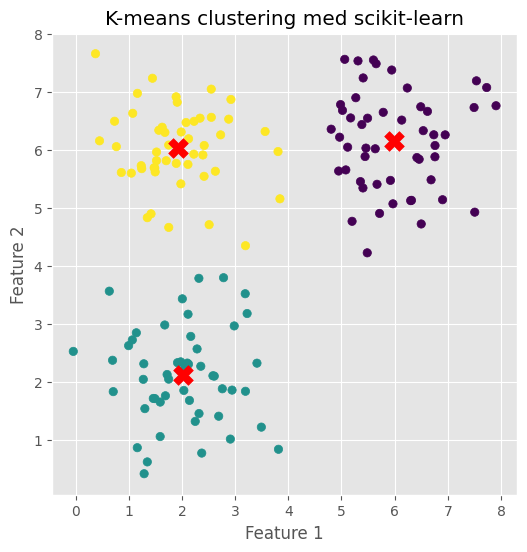

In [6]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, random_state=0)
labels = model.fit_predict(X)
centroids = model.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X")
plt.title("K-means clustering med scikit-learn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Værktøjer til estimering af cluster-antal

Når k-means er kørt, kan man vurdere kvaliteten af segmenteringen ved at se på:

- hvor kompakte klyngerne er (lav inertia)
- hvor godt de er adskilt (høj silhouette score)
- om centroids ligger meningsfuldt i forhold til data
- om klyngerne giver biologisk eller klinisk mening

Hvis man har "rigtige" labels, kan man også sammenligne med dem (fx accuracy, confusion matrix).



## To centrale mål:

- **Inertia**: summen af kvadrerede afstande fra hvert punkt til dets centroid
- **Silhouette score**: hvor godt et punkt passer i sin klynge sammenlignet med andre klynger

Disse bruges til at vurdere, om segmenteringen er god, og om k er rimeligt valgt.

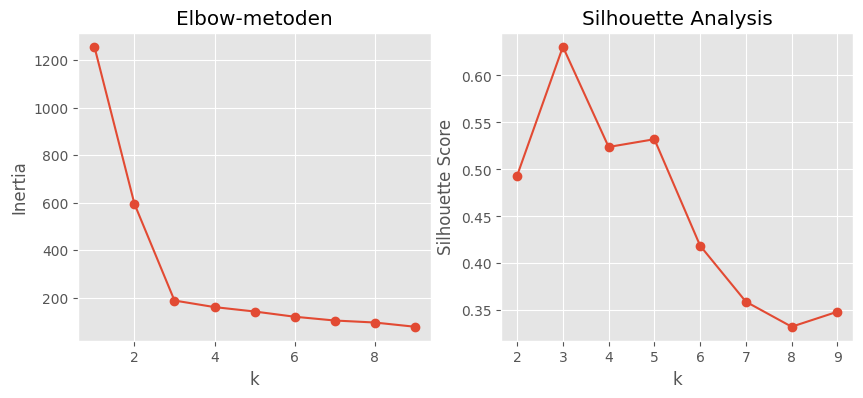

In [7]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
siluettes = []
ks = range(1, 10)
for k in ks:
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(X)
    inertias.append(model.inertia_)
    if k > 1:
        siluettes.append(silhouette_score(X, model.labels_))
    else:
        siluettes.append(float('nan'))  # or None
    model.get_params()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-metoden")

plt.subplot(1, 2, 2)
plt.plot(ks, siluettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

## Exercise: Martins glukose-gættekonkurrence

Scenarie:
Din chef Martin er lidt glemsom, og gider ikke gøre alting selv, så han kommer hen og giver dig følgende information, og opgave: "Jeg har ti glukosemålinger, men labels er væk. Jeg tror, der er 2 mønstre. Kan du ikke lige finde ud af det?"

Glukose (mg/dL): 171, 82, 118, 185, 78, 129, 165, 85, 178, 122

Opgave:

- Udfør k-means med 1 til 4 klynger, og vurder hvor mange klynger der er. 
- Argumenter for dit svar.

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">


## Svar

I følge Silhouete analyse er der 3 klynger. i følge Elbow metoden, så er der enten 2 eller 3. 

Når man plotter dataen så lader det til at være 3 klynger, så derfor vil jeg sige at der skal være 3 klynger. 

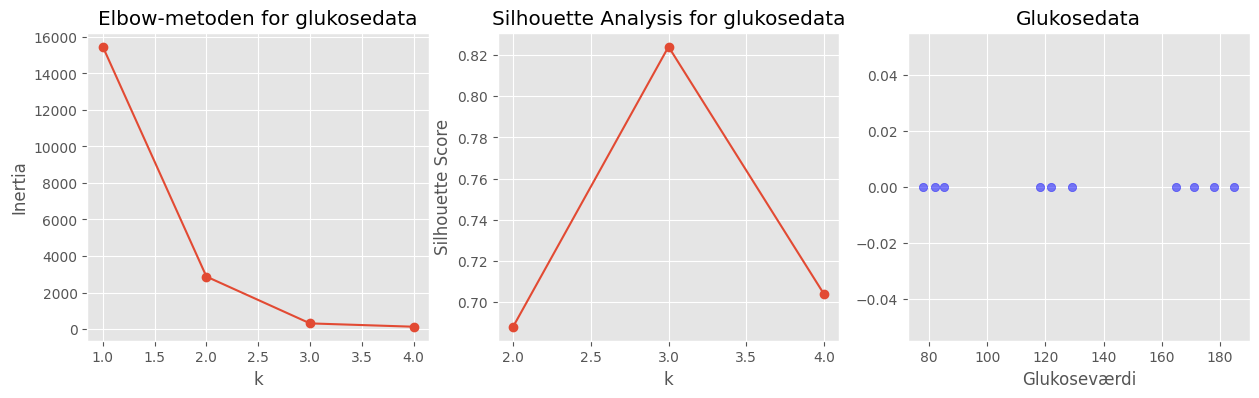

In [8]:
glukose_data = np.array([[171], [82], [118], [185], [78], [129], [165], [85], [178], [122]])
siluettes_glukose = []
innertias_glukose = []
for k in range(1, 5):
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(glukose_data)
    innertias_glukose.append(model.inertia_)
    if k > 1:
        siluettes_glukose.append(silhouette_score(glukose_data, model.labels_))
    else:
        siluettes_glukose.append(float('nan'))  # or None

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(range(1, 5), innertias_glukose, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-metoden for glukosedata")  
plt.subplot(1, 3, 2)
plt.plot(range(1, 5), siluettes_glukose, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for glukosedata")
plt.subplot(1, 3, 3)
plt.scatter(glukose_data[:, 0], np.zeros_like(glukose_data), c='blue', alpha=0.5)
plt.xlabel("Glukoseværdi")
plt.title("Glukosedata")
plt.show()

## Segmentering af billeder

K-means kan bruges til billedsegmentering ved at gruppere pixelintensiteter.

Workflow:

- Indlæs billedet som NumPy-matrix
- Fladgør billedet til en liste af pixels
- Kør k-means på pixelværdierne
- Form labels tilbage til billedets form
- Visualisér det segmenterede billede

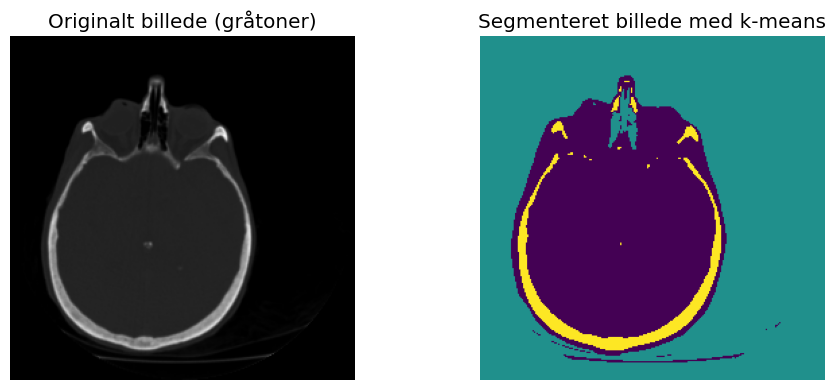

In [49]:
# Segmenter et billede fra URL med k-means, kun med skimage og sklearn
# Husk at installerer pooch, skimage og sklearn, hvis du ikke allerede har det:
from skimage import data
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
images_brain = data.brain()
image = images_brain[6,:,:]

# Fladgør billedet til en liste af pixels
pixels = image.reshape(-1, 1)

# Kør k-means på pixelværdierne
model_img = KMeans(n_clusters=3, random_state=0)
labels_img = model_img.fit_predict(pixels)

# Form labels tilbage til billedets form
segmented = labels_img.reshape(image.shape)

# Visualisér det originale og det segmenterede billede
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Originalt billede (gråtoner)")
plt.axis("off")

plt.subplot(1, 2, 2)
# plot segmented with a colormap that shows the different clusters clearly
plt.imshow(segmented, cmap="viridis")
plt.title("Segmenteret billede med k-means")
plt.axis("off")

plt.tight_layout()
plt.show()

# Scaling: Hvorfor skalere data?

- Mange machine learning-algoritmer (fx k-means, PCA, SVM, regression) er følsomme over for størrelsesforholdet mellem features.
- Features med store værdier kan dominere afstandsberegninger og modeltræning.
- Eksempel: Højde (i cm) og vægt (i kg) – vægten kan få større indflydelse, hvis den har større numerisk skala.
- Uskalerede data kan føre til dårlige eller misvisende resultater.




# Scaling: Hvornår er skalering vigtig?

- Når algoritmen bruger afstande (fx k-means, k-NN, PCA).
- Når features har forskellige enheder eller størrelsesordener.
- Skalering er ofte ikke nødvendig for træer (fx decision trees, random forest).
- Typiske metoder: MinMax-skalering (0-1), Standardisering (mean=0, std=1).
- God praksis: Skalér altid, hvis du er i tvivl!


# Scaling: Skalering med højde og BMI

Forestil dig et datasæt med to features:
- Højde i centimeter (fx 150–200)
- BMI (Body Mass Index, fx 18–35)

Hvis du bruger k-means clustering uden skalering, vil højden (fordi den har større numeriske værdier) dominere afstandsberegningen. Det betyder, at klyngerne primært opdeles efter højde, og BMI får næsten ingen betydning.

Hvis du derimod standardiserer begge features (så de har samme gennemsnit og standardafvigelse), får både højde og BMI lige stor indflydelse på klyngedannelsen. Det giver et mere retvisende resultat, hvor begge variable bidrager til analysen.

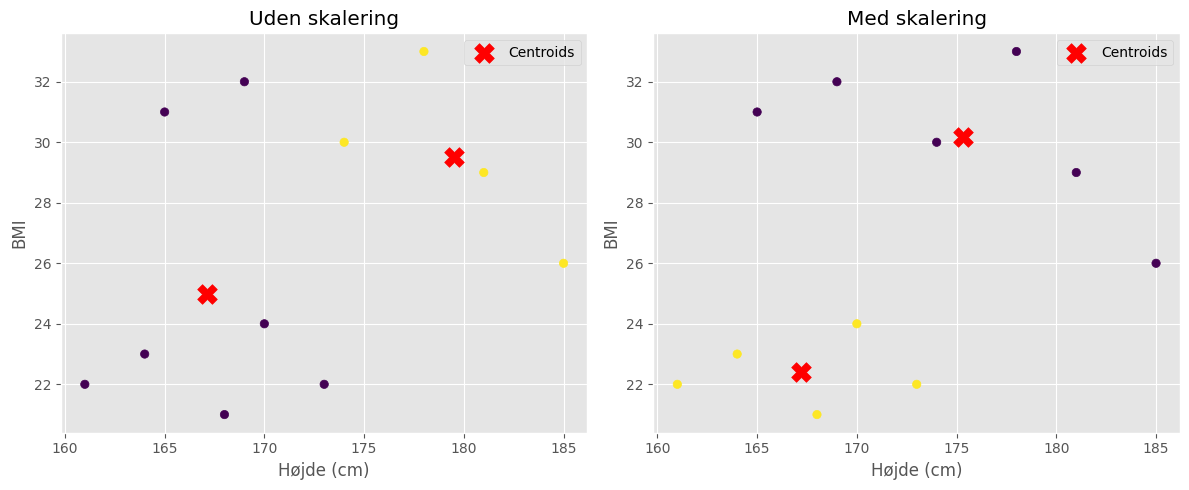

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Manually chosen heights (cm) and BMI (two groups)
X = np.array([
    [161, 22],
    [164, 23],
    [168, 21],
    [170, 24],
    [173, 22],
    [165, 31],
    [169, 32],
    [174, 30],
    [178, 33],
    [181, 29],
    [185, 26]
])

# K-means without scaling
model1 = KMeans(n_clusters=2, random_state=0)
labels1 = model1.fit_predict(X)
centroids1 = model1.cluster_centers_

# K-means with scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model2 = KMeans(n_clusters=2, random_state=0)
labels2 = model2.fit_predict(X_scaled)
centroids2 = scaler.inverse_transform(model2.cluster_centers_)  # transform back to original scale

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X[:, 0], X[:, 1], c=labels1)
axs[0].scatter(centroids1[:, 0], centroids1[:, 1], c="red", s=200, marker="X", label="Centroids")
axs[0].set_title("Uden skalering")
axs[0].set_xlabel("Højde (cm)")
axs[0].set_ylabel("BMI")
axs[0].legend()

axs[1].scatter(X[:, 0], X[:, 1], c=labels2)
axs[1].scatter(centroids2[:, 0], centroids2[:, 1], c="red", s=200, marker="X", label="Centroids")
axs[1].set_title("Med skalering")
axs[1].set_xlabel("Højde (cm)")
axs[1].set_ylabel("BMI")
axs[1].legend()

plt.tight_layout()
plt.show()

## Hvad man kan sige om data efter clustering

Efter clustering kan man fx beskrive:

- hvor mange naturlige grupper der opstår
- hvilke mønstre der findes i data
- hvilke features der adskiller grupperne
- om der er outliers eller meget små klynger
- om data ser symmetrisk, spredt, kompakt eller multimodal ud

I biomedicinsk kontekst kan man fx sige:

- om der er forskellige fysiologiske tilstande
- om der er patientgrupper med forskellige risikoprofiler
- om et billede kan opdeles i meningsfulde vævssegmenter

# Opgaver


<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# **Opgave: 'Iris Klynge-Gåden'**  

### Scenarie  
Din excentriske chef, Dr. Martin von Flowerlover, stormer ind på kontoret med et glimt i øjet og et berømt datasæt i hånden. Han siger:  

'Jeg har målinger fra en mystisk have: bægerbladslængde, bægerbladsbredde, kronbladslængde og kronbladsbredde for en masse blomster. Men jeg aner ikke, hvor mange blomsterarter der egentlig er! Brug dine Hacker skillz (sorry jeg blev nød til det) til at finde uf af hvor mange bloster typer der er .'

### Hvad du ved efter forelæsningen  
- Hvordan man bruger NumPy-arrays og scikit-learn til clustering.  
- Hvordan man skalerer features for retfærdig sammenligning.  
- Hvordan man kører `KMeans` og visualiserer klynger.
- Ved hvad silluett og innertia er.

### Opgave  
- Indlæs det kendte iris-datasætt, vurder hvor mange klynger ved hjælp af de metoder du kender til nu. 
- Hvor mange forskellige blomsterarter mener du, der er, hvis man benytter features: `pedal width` og `length width`? 
    - Begrund dit svar med plots og klynge-evalueringsmetrikker.
- Visualiser 2 udvalgte features (`pedal width` og `pedal width`) for det antal klynger i er blevet enige om. Og plot for features (Bare plot det scaleret)
    - Husk at give figuren x og y label


*Hint: Det er en god ide at scale dit data.*  
*Hint: Du kan gå datasættet ved at kører følgende script.*  
*Hint: Data er gemt som en dictionary, så undersøg hvad den indeholder, i.e. med at se på `data.keys()`, for at se de forskellige elementer, og i.e. `data.feature_names`, for at se feature navnene*
*Hint: Hvis du ikke kan downloade datasættet og den siger noget om at du mangler noget som hedder `pooch`, så kan du installerer det med din package manager (`conda install conda-forge::pooch` / `uv add poock` / `pip install pooch`)
>```python
>from sklearn.datasets import load_iris
>from sklearn.preprocessing import StandardScaler
>data = load_iris()
>X = StandardScaler().fit_transform(data.data)
>feature1 = X[:,0]
>```


<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

## Svar:
- Silhouette Scoren lader til altid at hentyde til at der vil være 2 klynger, hvilket også kan give god mening når man ser på features som er plottet.
- Men Elbow Method lader til mere at være 3 klynger.
    - Der er faktisk 3 grupper, som man også kan se hvis man læser dokumentationen for datasættet. (Hvis du har valgt 2 klynger forstår jeg det godt, men husk at skriv at de 2 metoder viser lidt forskellige ting)


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


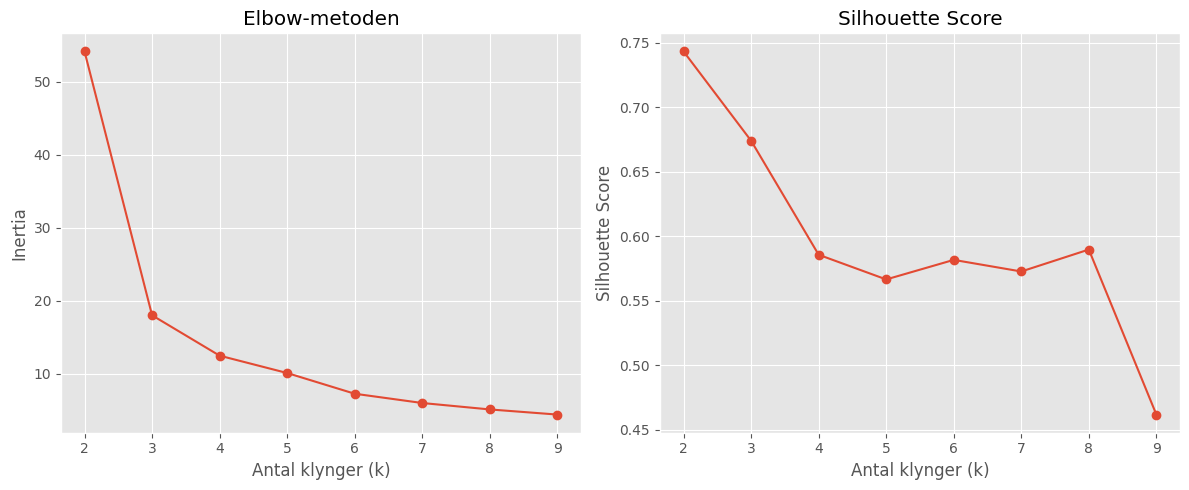

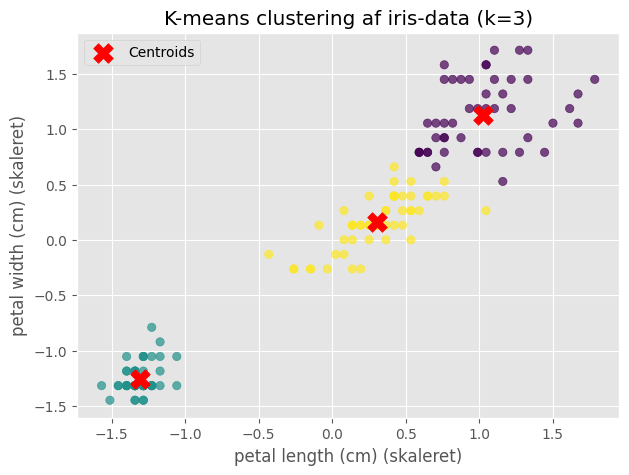

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Indlæs og skaler data
data = load_iris()
print(data.keys())
selected_features = [2,3]  # Vælg de sidste to features (petal length og petal width)
X = StandardScaler().fit_transform(data.data)[:,selected_features] # Brug kun de første to features for visualisering

inertias = []
silhouettes = []
ks = range(2, 10)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Plot inertia og silhouette score
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(ks, inertias, marker='o')
ax[0].set_xlabel('Antal klynger (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow-metoden')

ax[1].plot(ks, silhouettes, marker='o')
ax[1].set_xlabel('Antal klynger (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

# Visualiser klynger for k=3
k = 3
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(X)
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.xlabel(f'{data.feature_names[selected_features[0]]} (skaleret)')
plt.ylabel(f'{data.feature_names[selected_features[1]]} (skaleret)')
plt.title('K-means clustering af iris-data (k=3)')
plt.legend()
plt.show()

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">


# **Opgave: Automatisk segmentering af nethindebillede og blodkar med k-means**  


### Scenarie  
Din chef Martin har nu fundet et nethindebillede fra skimage's datasæt. Han siger:  
'Jeg vil gerne kunne se blodårerne i øjet tydeligt, men jeg gider ikke gøre det manuelt! Kan du bruge clustering til at segmentere billedet, så blodårerne fremstår tydeligt?'


### Hvad du ved efter forelæsningen  
- Hvordan man indlæser billeder som NumPy arrays fra skimage.data.  
- Hvordan man fladgør billedet til en vektor af pixelværdier.  
- Hvordan man bruger k-means clustering til at gruppere pixels.  
- Hvordan man former labels tilbage til billedets form og visualiserer resultatet.


### Opgave  
1. Indlæs nethindebilledet fra skimage.data med `from skimage import data` og `image = data.retina()[:,:,1]` (brug farve kanal 1, den grønne kanal, hvor blodårer ofte ses tydeligst).
2. Prøv at segmentere billedet med forskellige antal klynger (k=2, 3, 4, 5,6,7).
3. Visualisér både det originale billede og de segmenterede billeder for hvert k (hvor klyngerne vises med forskellige farver).
4. Diskutér: Hvilket antal klynger giver den bedste fremhævning af blodårerne?
5. Kommentér på, om clustering giver en meningsfuld opdeling af billedet, og hvordan det kan bruges til at identificere blodårer.


*Hint: Brug plt.imshow til at vise billederne. Hvis du får fejl om 'pooch', så installer pakken med pip eller conda.*


</div>

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">


## Svar:


- Blodårerne i nethindebilledet fremstår tydeligst, når man vælger et passende antal klynger (ofte k=3 eller k=4).
- For få klynger (k=2) adskiller kun groft forgrund/baggrund, mens flere klynger kan adskille blodårer, baggrund og andre vævstyper.
- Den grønne kanal fremhæver blodårerne bedst, da kontrasten mellem blodkar og væv er størst her.
- Man kan vurdere det bedste k ved at se, hvornår blodårerne bliver tydeligt adskilt fra baggrunden uden at billedet bliver for "plettet".
- Clustering kan bruges som et første skridt til automatisk at identificere blodårer, men kræver ofte efterbehandling for at fjerne støj og små segmenter.
</div>

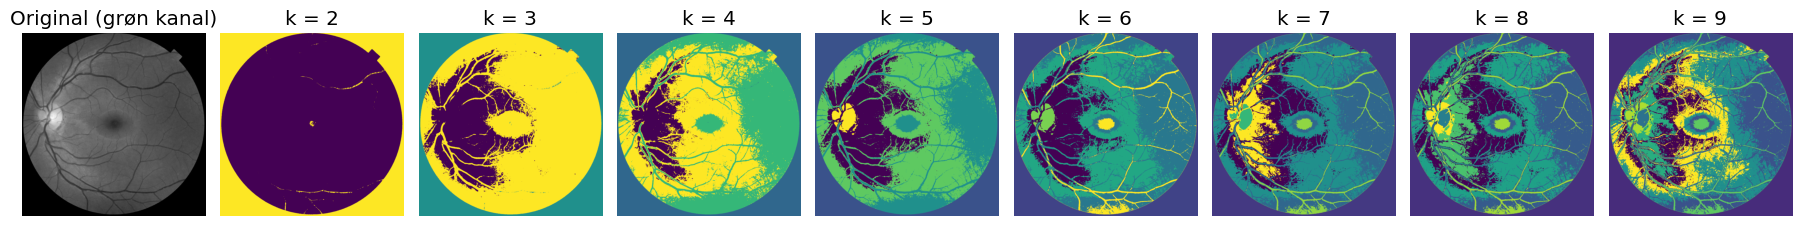

In [53]:
# Segmentering af nethindebillede med k-means for at fremhæve blodårer
from skimage import data
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Indlæs nethindebilledet og vælg grøn kanal
image = data.retina()[:,:,1]

# Fladgør billedet til en liste af pixels
pixels = image.reshape(-1, 1)

ks = list(range(2,10))
fig, axs = plt.subplots(1, len(ks)+1, figsize=(18, 5))

# Vis originalt billede
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Original (grøn kanal)")
axs[0].axis("off")

# Segmentér og vis for hvert k
for i, k in enumerate(ks):
    model = KMeans(n_clusters=k, random_state=0)
    labels = model.fit_predict(pixels)
    segmented = labels.reshape(image.shape)
    axs[i+1].imshow(segmented, cmap="viridis")
    axs[i+1].set_title(f"k = {k}")
    axs[i+1].axis("off")

plt.tight_layout()
plt.show()